# Exploratory Data Analysis — Xente Credit Risk Dataset

**Project:** Bati Bank Credit Risk Model  
**Dataset:** Xente eCommerce transaction data (~95k rows, 16 columns)  
**Goal:** Uncover patterns, identify data quality issues, and form hypotheses to guide feature engineering and proxy target variable design.

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = sns.color_palette("muted")

DATA_PATH = "../data/raw/data.csv"
RANDOM_STATE = 42
os.makedirs("../data/processed", exist_ok=True)

---
## 1. Overview of the Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["TransactionStartTime"])
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df.TransactionStartTime.min()} -> {df.TransactionStartTime.max()}")
df.head(3)

Shape: 95,662 rows x 16 columns
Date range: 2018-11-15 02:18:49+00:00 -> 2019-02-13 10:01:28+00:00


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,"1,000.00",1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.00,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.00,500,2018-11-15 02:44:21+00:00,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  object             
 1   BatchId               95662 non-null  object             
 2   AccountId             95662 non-null  object             
 3   SubscriptionId        95662 non-null  object             
 4   CustomerId            95662 non-null  object             
 5   CurrencyCode          95662 non-null  object             
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  object             
 8   ProductId             95662 non-null  object             
 9   ProductCategory       95662 non-null  object             
 10  ChannelId             95662 non-null  object             
 11  Amount                95662 non-null  float64            
 12  Valu

In [4]:
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(),
    "sample": df.iloc[0]
})
overview

,dtype,non_null,null_count,null_pct,unique,sample
TransactionId,object,95662,0,0.00,95662,TransactionId_76871
BatchId,object,95662,0,0.00,94809,BatchId_36123
AccountId,object,95662,0,0.00,3633,AccountId_3957
SubscriptionId,object,95662,0,0.00,3627,SubscriptionId_887
CustomerId,object,95662,0,0.00,3742,CustomerId_4406
CurrencyCode,object,95662,0,0.00,1,UGX
CountryCode,int64,95662,0,0.00,1,256
ProviderId,object,95662,0,0.00,6,ProviderId_6
ProductId,object,95662,0,0.00,23,ProductId_10
ProductCategory,object,95662,0,0.00,9,airtime


In [5]:
ID_COLS = ["TransactionId", "BatchId", "AccountId", "SubscriptionId", "CustomerId"]
NUM_COLS = ["Amount", "Value"]
CAT_COLS = ["CurrencyCode", "CountryCode", "ProviderId", "ProductId",
            "ProductCategory", "ChannelId", "PricingStrategy", "FraudResult"]
TIME_COL = "TransactionStartTime"

print(f"Unique customers  : {df.CustomerId.nunique():,}")
print(f"Unique accounts   : {df.AccountId.nunique():,}")
print(f"Unique products   : {df.ProductId.nunique():,}")
print(f"Fraud transactions: {df.FraudResult.sum():,} ({df.FraudResult.mean()*100:.2f}%)")

Unique customers  : 3,742
Unique accounts   : 3,633
Unique products   : 23
Fraud transactions: 193 (0.20%)


---
## 2. Summary Statistics

In [6]:
df[NUM_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Amount,"95,662.00","6,717.85","123,306.80","-1,000,000.00","-30,000.00","-5,000.00",-50.00,"1,000.00","2,800.00","14,500.00","80,000.00","9,880,000.00"
Value,"95,662.00","9,900.58","123,122.09",2.00,10.00,25.00,275.00,"1,000.00","5,000.00","25,000.00","90,000.00","9,880,000.00"


In [7]:
sk = df[NUM_COLS].agg(["skew", "kurtosis"]).T
sk.columns = ["Skewness", "Kurtosis"]
print("Skewness and Kurtosis:")
print(sk.to_string())
print("Note: |skew| > 1 = highly skewed; kurtosis >> 3 = heavy-tailed (leptokurtic)")

Skewness and Kurtosis:
        Skewness  Kurtosis
Amount     51.10  3,363.13
Value      51.29  3,378.07
Note: |skew| > 1 = highly skewed; kurtosis >> 3 = heavy-tailed (leptokurtic)


In [8]:
print("Amount sign breakdown:")
print(f"  Positive (debits) : {(df.Amount > 0).sum():>7,}  ({(df.Amount > 0).mean()*100:.1f}%)")
print(f"  Negative (credits): {(df.Amount < 0).sum():>7,}  ({(df.Amount < 0).mean()*100:.1f}%)")
print(f"  Zero              : {(df.Amount == 0).sum():>7,}  ({(df.Amount == 0).mean()*100:.1f}%)")
print(f"Amount == abs(Value) check: {(df.Amount.abs() == df.Value).mean()*100:.1f}% of rows")

Amount sign breakdown:
  Positive (debits) :  57,473  (60.1%)
  Negative (credits):  38,189  (39.9%)
  Zero              :       0  (0.0%)
Amount == abs(Value) check: 97.3% of rows


In [9]:
cust_stats = df.groupby("CustomerId").agg(
    tx_count=("TransactionId", "count"),
    total_spend=("Value", "sum"),
    mean_tx=("Value", "mean"),
    max_tx=("Value", "max")
)
print("Per-customer statistics:")
cust_stats.describe(percentiles=[.5, .75, .95, .99]).T

Per-customer statistics:


,count,mean,std,min,50%,75%,95%,99%,max
tx_count,"3,742.00",25.56,96.93,1.00,7.00,20.00,98.00,275.95,"4,091.00"
total_spend,"3,742.00","253,102.53","2,715,876.81",50.00,"32,000.00","102,060.00","610,077.10","2,298,401.84","104,900,000.00"
mean_tx,"3,742.00","18,756.12","167,452.89",50.00,"3,950.00","7,096.04","45,820.74","304,969.11","8,601,821.14"
max_tx,"3,742.00","53,378.60","360,448.90",50.00,"10,000.00","20,000.00","106,300.00","993,850.00","9,880,000.00"


---
## 3. Distribution of Numerical Features

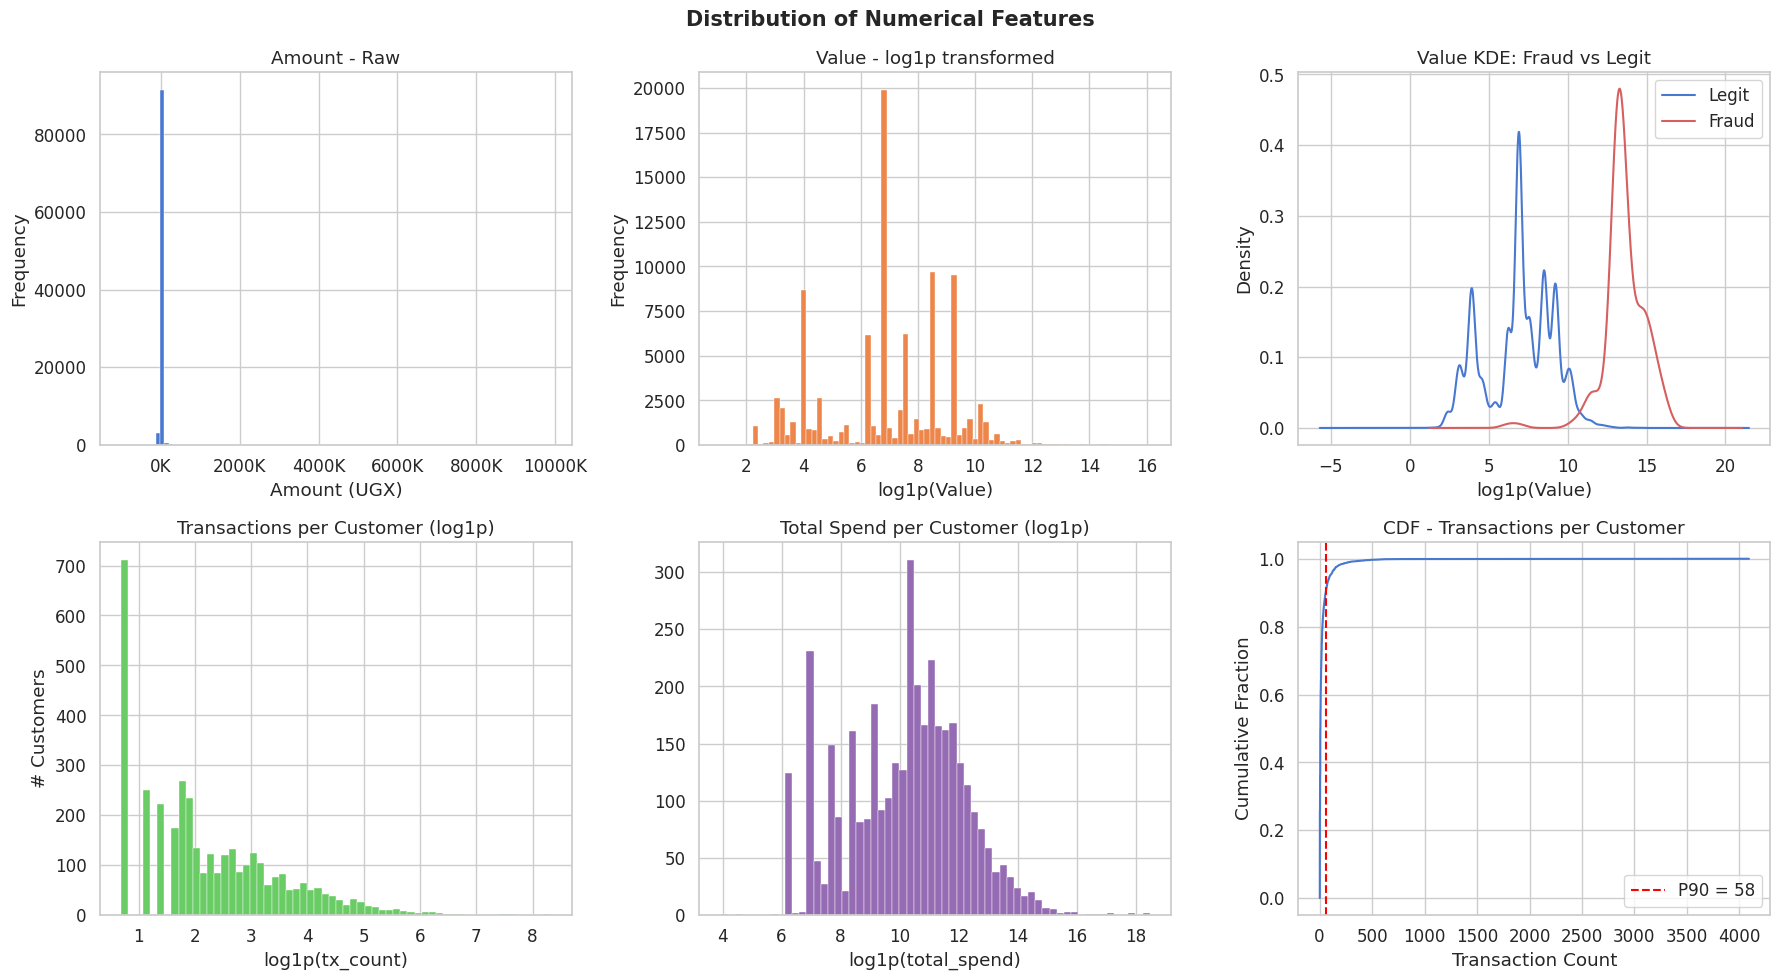

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribution of Numerical Features", fontsize=15, fontweight="bold")

axes[0, 0].hist(df["Amount"], bins=100, color=COLORS[0], edgecolor="white", linewidth=0.3)
axes[0, 0].set_title("Amount - Raw")
axes[0, 0].set_xlabel("Amount (UGX)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

log_val = np.log1p(df["Value"])
axes[0, 1].hist(log_val, bins=80, color=COLORS[1], edgecolor="white", linewidth=0.3)
axes[0, 1].set_title("Value - log1p transformed")
axes[0, 1].set_xlabel("log1p(Value)")
axes[0, 1].set_ylabel("Frequency")

for label, color, name in [(0, COLORS[0], "Legit"), (1, COLORS[3], "Fraud")]:
    grp = df[df["FraudResult"] == label]["Value"]
    np.log1p(grp).plot.kde(ax=axes[0, 2], label=name,
                            color=COLORS[3] if label == 1 else COLORS[0])
axes[0, 2].set_title("Value KDE: Fraud vs Legit")
axes[0, 2].set_xlabel("log1p(Value)")
axes[0, 2].legend()

axes[1, 0].hist(np.log1p(cust_stats["tx_count"]), bins=60, color=COLORS[2], edgecolor="white", linewidth=0.3)
axes[1, 0].set_title("Transactions per Customer (log1p)")
axes[1, 0].set_xlabel("log1p(tx_count)")
axes[1, 0].set_ylabel("# Customers")

axes[1, 1].hist(np.log1p(cust_stats["total_spend"]), bins=60, color=COLORS[4], edgecolor="white", linewidth=0.3)
axes[1, 1].set_title("Total Spend per Customer (log1p)")
axes[1, 1].set_xlabel("log1p(total_spend)")

sorted_counts = np.sort(cust_stats["tx_count"])
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1, 2].plot(sorted_counts, cdf, color=COLORS[0])
p90_idx = int(0.9 * len(sorted_counts))
axes[1, 2].axvline(sorted_counts[p90_idx], color="red", linestyle="--",
                   label=f"P90 = {sorted_counts[p90_idx]}")
axes[1, 2].set_title("CDF - Transactions per Customer")
axes[1, 2].set_xlabel("Transaction Count")
axes[1, 2].set_ylabel("Cumulative Fraction")
axes[1, 2].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_numerical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

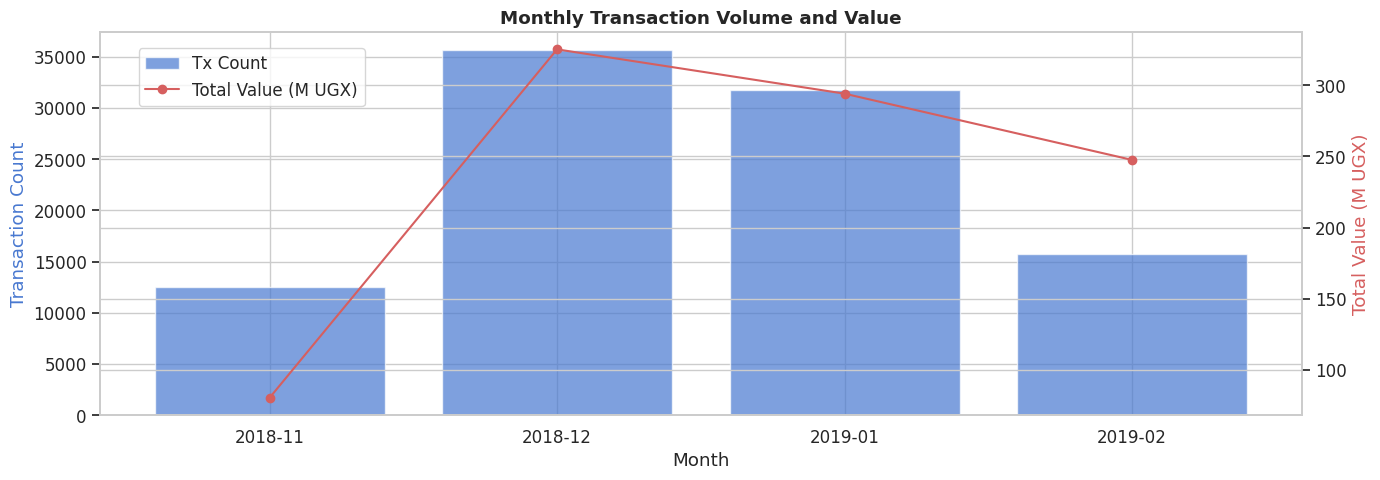

In [11]:
df["month"] = df[TIME_COL].dt.to_period("M")
monthly = df.groupby("month").agg(
    tx_count=("TransactionId", "count"),
    total_value=("Value", "sum")
).reset_index()
monthly["month_str"] = monthly["month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(monthly["month_str"], monthly["tx_count"], color=COLORS[0], alpha=0.7, label="Tx Count")
ax2.plot(monthly["month_str"], monthly["total_value"] / 1e6, color=COLORS[3], marker="o", label="Total Value (M UGX)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Transaction Count", color=COLORS[0])
ax2.set_ylabel("Total Value (M UGX)", color=COLORS[3])
ax1.set_title("Monthly Transaction Volume and Value", fontweight="bold")
plt.xticks(rotation=45, ha="right")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig("../data/processed/eda_monthly_volume.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Distribution of Categorical Features

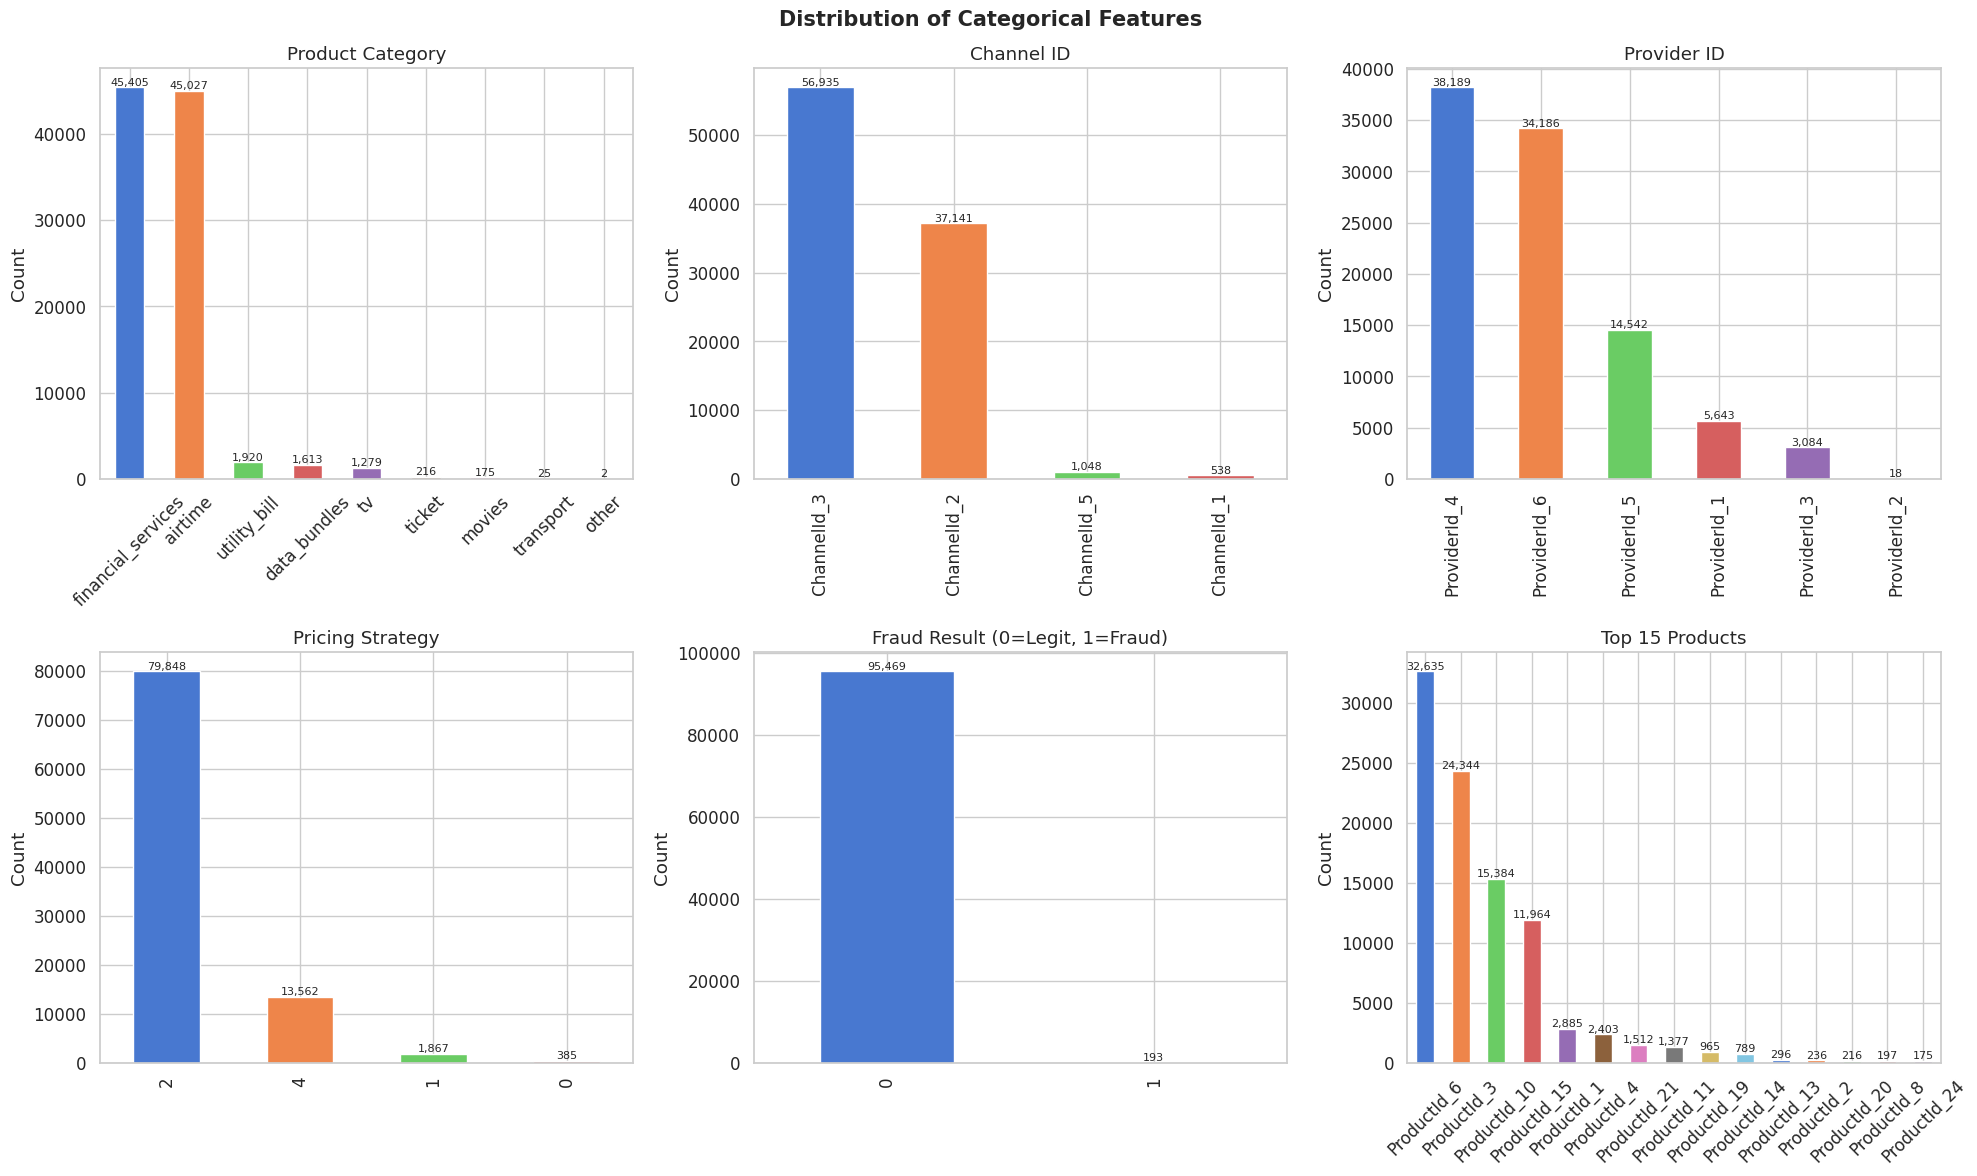

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Distribution of Categorical Features", fontsize=15, fontweight="bold")

def bar_chart(ax, series, title, top_n=None, rotate=False):
    vc = series.value_counts()
    if top_n:
        vc = vc.head(top_n)
    vc.plot.bar(ax=ax, color=COLORS[:len(vc)], edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", fontsize=8)
    if rotate:
        ax.tick_params(axis="x", rotation=45)

bar_chart(axes[0, 0], df["ProductCategory"], "Product Category", rotate=True)
bar_chart(axes[0, 1], df["ChannelId"], "Channel ID")
bar_chart(axes[0, 2], df["ProviderId"], "Provider ID")
bar_chart(axes[1, 0], df["PricingStrategy"].astype(str), "Pricing Strategy")
bar_chart(axes[1, 1], df["FraudResult"].astype(str), "Fraud Result (0=Legit, 1=Fraud)")
bar_chart(axes[1, 2], df["ProductId"], "Top 15 Products", top_n=15, rotate=True)

plt.tight_layout()
plt.savefig("../data/processed/eda_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

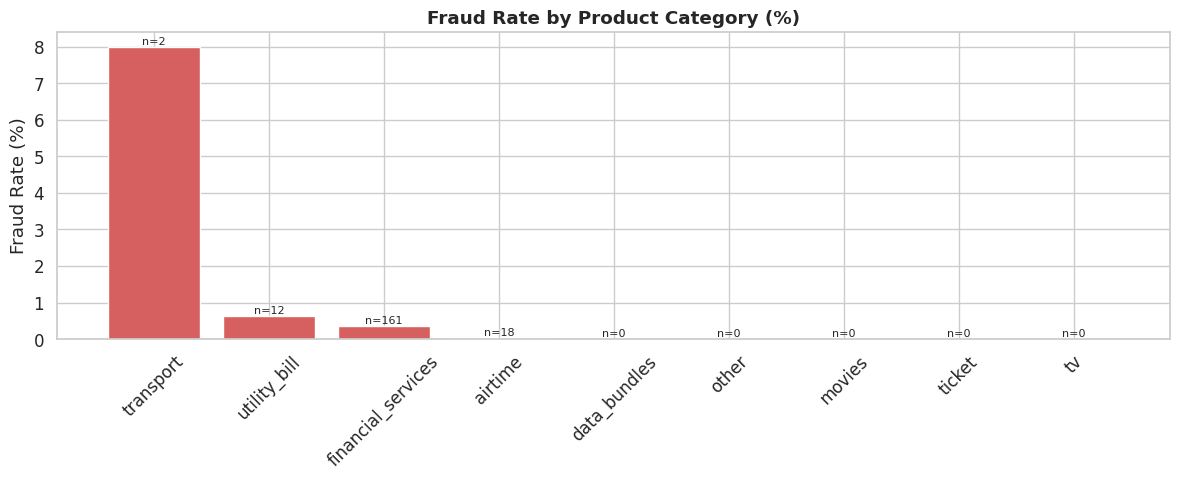

,fraud_rate,fraud_count,total_tx
ProductCategory,,,
transport,0.08,2,25
utility_bill,0.01,12,1920
financial_services,0.00,161,45405
airtime,0.00,18,45027
data_bundles,0.00,0,1613
other,0.00,0,2
movies,0.00,0,175
ticket,0.00,0,216
tv,0.00,0,1279


In [13]:
fraud_by_cat = df.groupby("ProductCategory")["FraudResult"].agg(["mean", "sum", "count"])
fraud_by_cat.columns = ["fraud_rate", "fraud_count", "total_tx"]
fraud_by_cat = fraud_by_cat.sort_values("fraud_rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(fraud_by_cat.index, fraud_by_cat["fraud_rate"] * 100, color=COLORS[3], edgecolor="white")
ax.set_title("Fraud Rate by Product Category (%)", fontweight="bold")
ax.set_ylabel("Fraud Rate (%)")
ax.tick_params(axis="x", rotation=45)
for bar, count in zip(bars, fraud_by_cat["fraud_count"]):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
            f"n={count}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/eda_fraud_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
fraud_by_cat

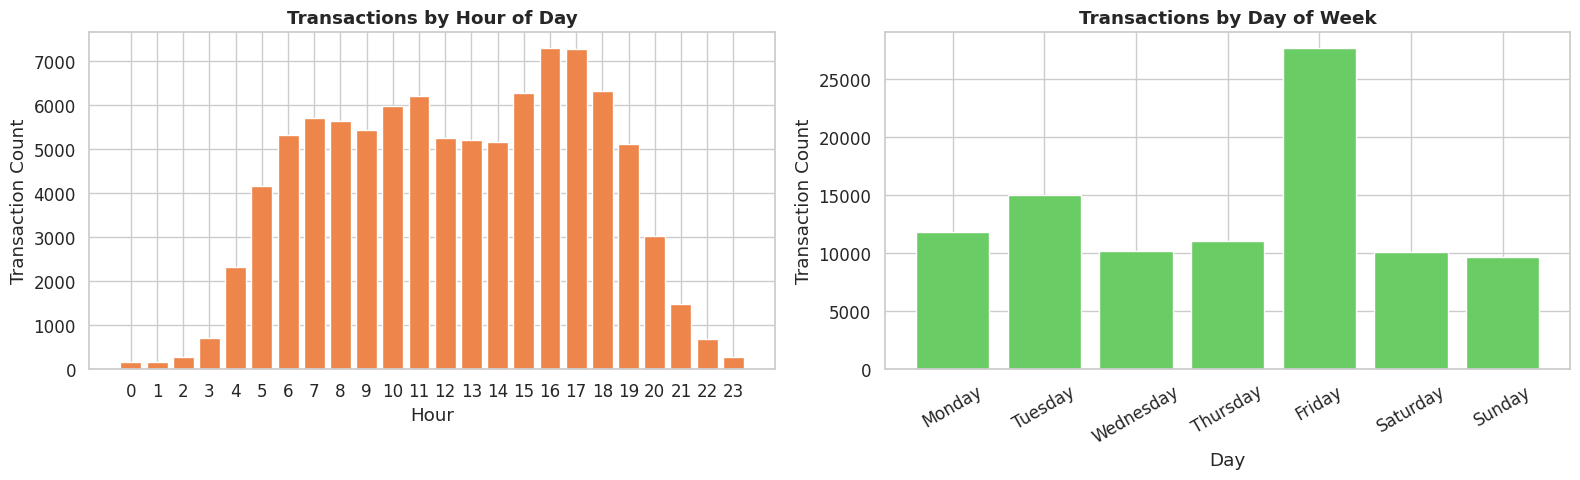

In [14]:
df["hour"] = df[TIME_COL].dt.hour
df["dayofweek"] = df[TIME_COL].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly = df.groupby("hour").size()
axes[0].bar(hourly.index, hourly.values, color=COLORS[1], edgecolor="white")
axes[0].set_title("Transactions by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Transaction Count")
axes[0].set_xticks(range(0, 24))

daily = df.groupby("dayofweek").size().reindex(day_order)
axes[1].bar(daily.index, daily.values, color=COLORS[2], edgecolor="white")
axes[1].set_title("Transactions by Day of Week", fontweight="bold")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Transaction Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../data/processed/eda_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Correlation Analysis

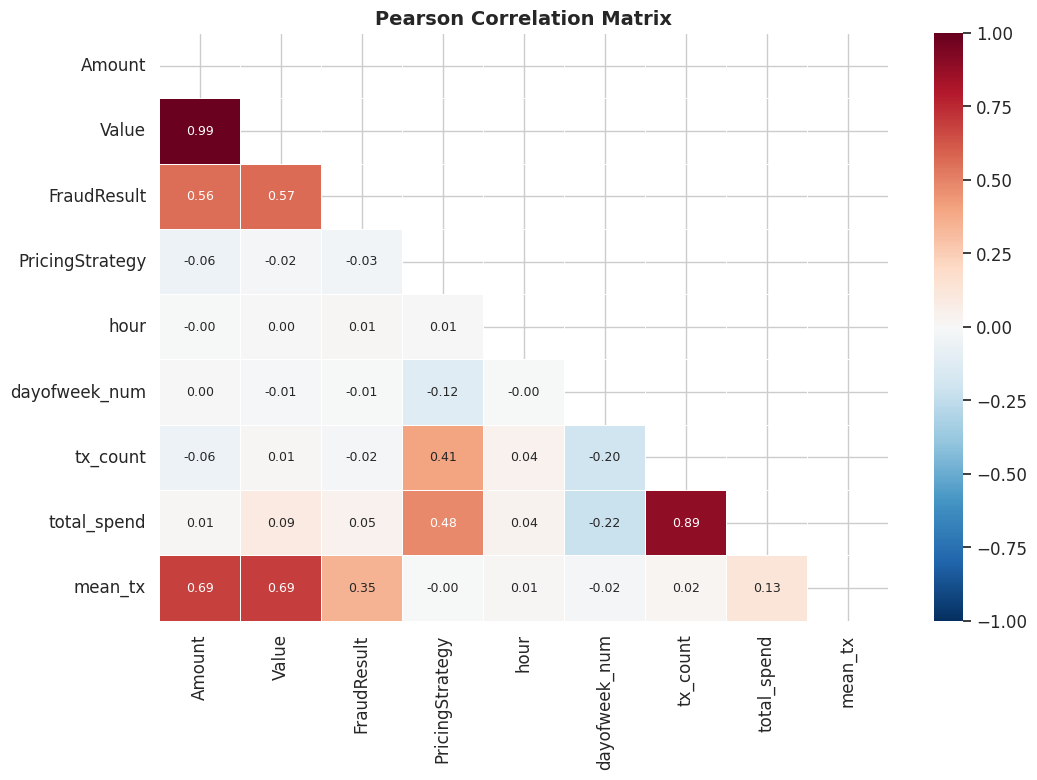

In [15]:
corr_df = df[["Amount", "Value", "FraudResult", "PricingStrategy", "hour"]].copy()
corr_df["dayofweek_num"] = pd.Categorical(df["dayofweek"], categories=day_order).codes
corr_df["tx_count"] = cust_stats.loc[df["CustomerId"], "tx_count"].values
corr_df["total_spend"] = cust_stats.loc[df["CustomerId"], "total_spend"].values
corr_df["mean_tx"] = cust_stats.loc[df["CustomerId"], "mean_tx"].values

corr_matrix = corr_df.corr(method="pearson")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Pearson Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../data/processed/eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

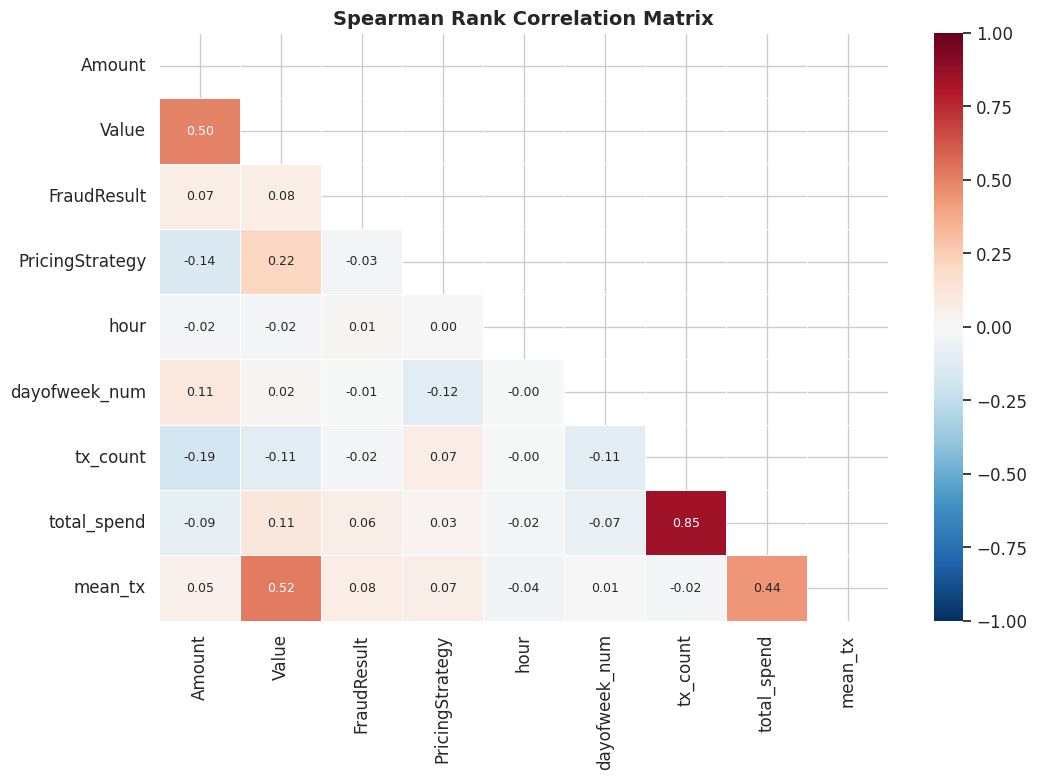

In [16]:
spearman_matrix = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(spearman_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Spearman Rank Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../data/processed/eda_spearman_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

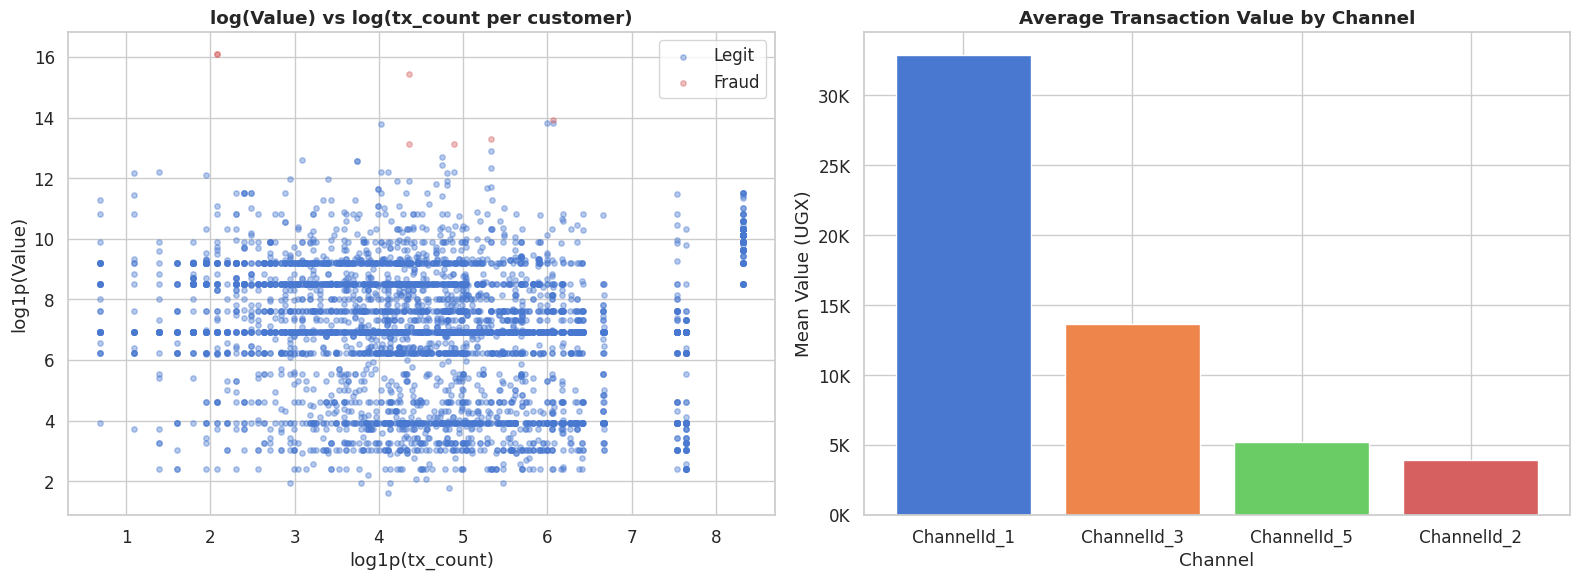

In [17]:
sample = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, color, name in [(0, COLORS[0], "Legit"), (1, COLORS[3], "Fraud")]:
    sub = sample[sample["FraudResult"] == label]
    sub_tx = cust_stats.loc[sub["CustomerId"].values, "tx_count"].values
    axes[0].scatter(np.log1p(sub_tx), np.log1p(sub["Value"].values),
                    alpha=0.4, c=color, label=name, s=15)

axes[0].set_title("log(Value) vs log(tx_count per customer)", fontweight="bold")
axes[0].set_xlabel("log1p(tx_count)")
axes[0].set_ylabel("log1p(Value)")
axes[0].legend()

channel_avg = df.groupby("ChannelId")["Value"].mean().sort_values(ascending=False)
axes[1].bar(channel_avg.index, channel_avg.values, color=COLORS[:len(channel_avg)], edgecolor="white")
axes[1].set_title("Average Transaction Value by Channel", fontweight="bold")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Mean Value (UGX)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig("../data/processed/eda_scatter_channel.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Missing Value Analysis

Missing values per column:
No missing values found.


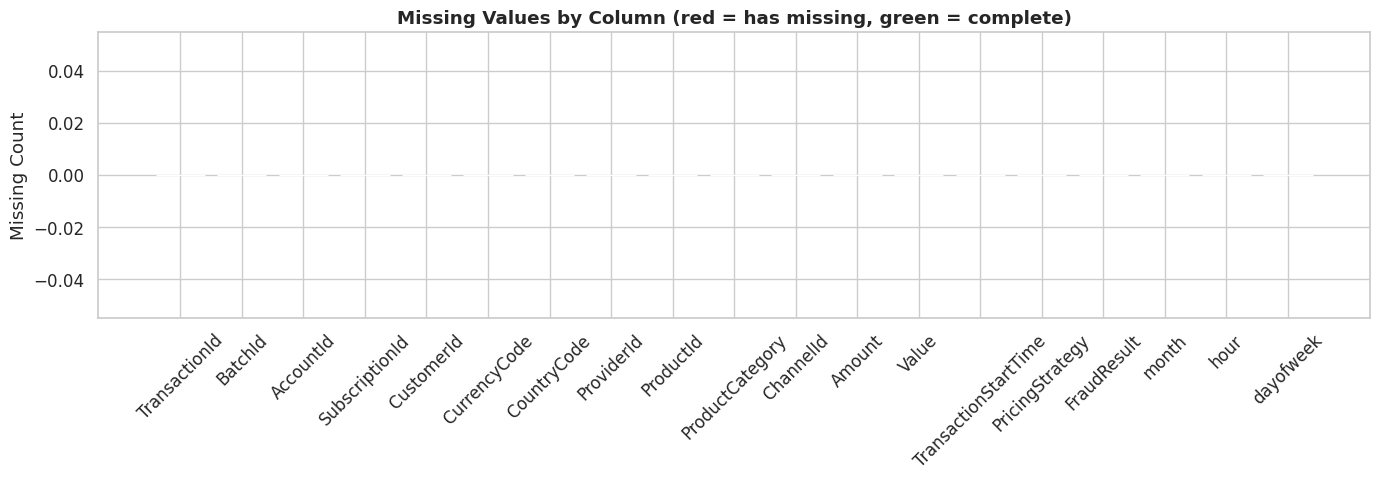

In [18]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(4)

print("Missing values per column:")
missing_report = pd.DataFrame({"count": missing, "pct": missing_pct})
if missing.sum() > 0:
    print(missing_report[missing_report["count"] > 0].to_string())
else:
    print("No missing values found.")

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in missing.values]
ax.bar(missing.index, missing.values, color=colors, edgecolor="white")
ax.set_title("Missing Values by Column (red = has missing, green = complete)", fontweight="bold")
ax.set_ylabel("Missing Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/eda_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
dup_transactions = df["TransactionId"].duplicated().sum()
dup_rows = df.duplicated().sum()
print(f"Duplicate TransactionIds: {dup_transactions}")
print(f"Fully duplicate rows    : {dup_rows}")

zero_value = (df["Value"] == 0).sum()
print(f"Zero-Value transactions : {zero_value} ({zero_value/len(df)*100:.2f}%)")

Duplicate TransactionIds: 0
Fully duplicate rows    : 0
Zero-Value transactions : 0 (0.00%)


---
## 7. Outlier Detection

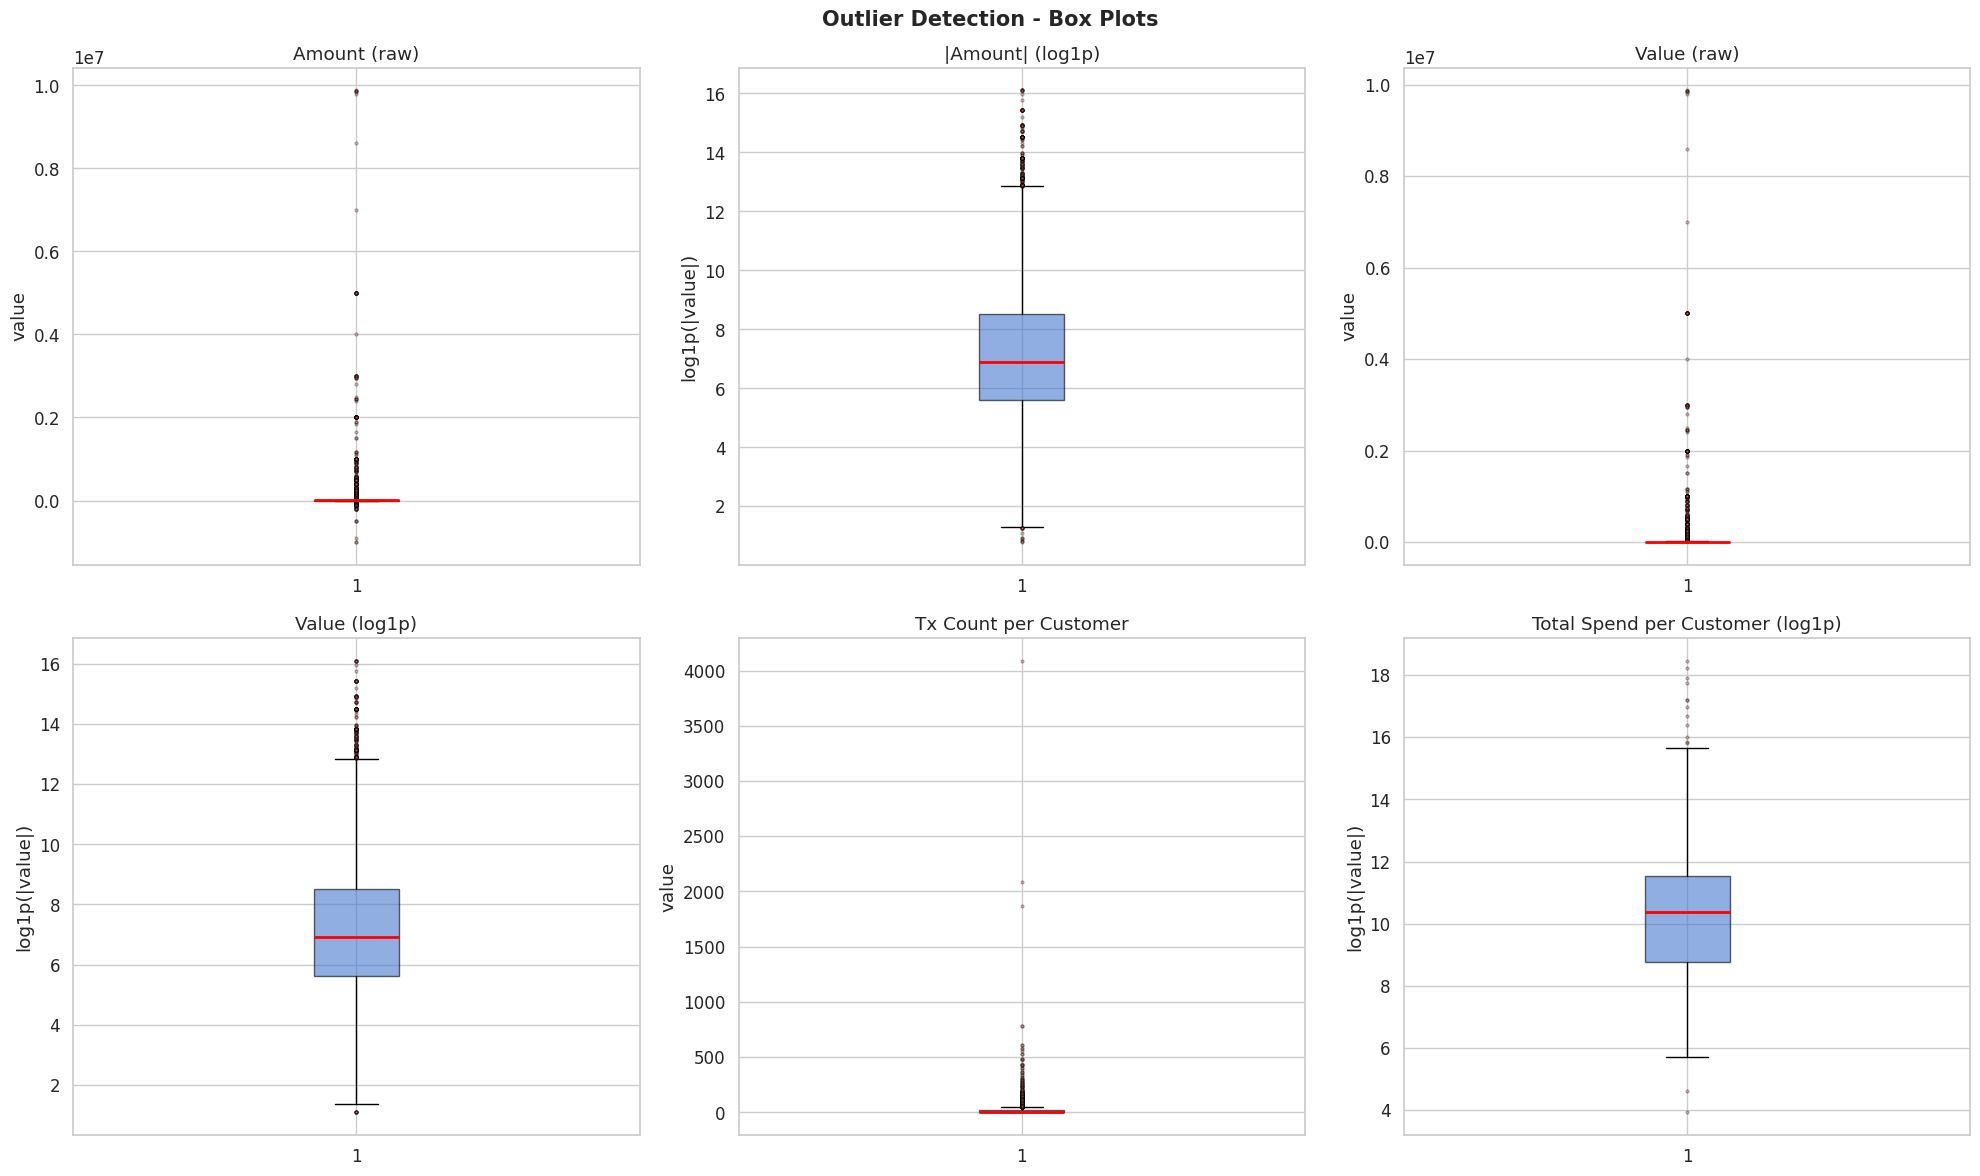

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Outlier Detection - Box Plots", fontsize=15, fontweight="bold")

def boxplot(ax, data, title, log=False):
    plot_data = np.log1p(data.abs()) if log else data
    clean = plot_data.replace([np.inf, -np.inf], np.nan).dropna()
    ax.boxplot(clean, vert=True, patch_artist=True,
               boxprops=dict(facecolor=COLORS[0], alpha=0.6),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markersize=2, alpha=0.3, markerfacecolor=COLORS[3]))
    ax.set_title(title)
    ax.set_ylabel("log1p(|value|)" if log else "value")

boxplot(axes[0, 0], df["Amount"], "Amount (raw)")
boxplot(axes[0, 1], df["Amount"].abs(), "|Amount| (log1p)", log=True)
boxplot(axes[0, 2], df["Value"], "Value (raw)")
boxplot(axes[1, 0], df["Value"], "Value (log1p)", log=True)
boxplot(axes[1, 1], cust_stats["tx_count"], "Tx Count per Customer")
boxplot(axes[1, 2], cust_stats["total_spend"], "Total Spend per Customer (log1p)", log=True)

plt.tight_layout()
plt.savefig("../data/processed/eda_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
def iqr_outlier_stats(series, name):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return {"feature": name, "Q1": q1, "Q3": q3, "IQR": iqr,
            "lower_fence": lower, "upper_fence": upper,
            "n_outliers": n_out, "outlier_pct": round(n_out / len(series) * 100, 2)}

outlier_summary = pd.DataFrame([
    iqr_outlier_stats(df["Amount"], "Amount"),
    iqr_outlier_stats(df["Value"], "Value"),
    iqr_outlier_stats(cust_stats["tx_count"], "tx_count (per customer)"),
    iqr_outlier_stats(cust_stats["total_spend"], "total_spend (per customer)"),
    iqr_outlier_stats(cust_stats["mean_tx"], "mean_tx (per customer)"),
]).set_index("feature")
outlier_summary

,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_pct
feature,,,,,,,
Amount,-50.00,"2,800.00","2,850.00","-4,325.00","7,075.00",24441,25.55
Value,275.00,"5,000.00","4,725.00","-6,812.50","12,087.50",9021,9.43
tx_count (per customer),2.00,20.00,18.00,-25.00,47.00,448,11.97
total_spend (per customer),"6,500.00","102,060.00","95,560.00","-136,840.00","245,400.00",441,11.79
mean_tx (per customer),"1,160.66","7,096.04","5,935.38","-7,742.42","15,999.12",337,9.01


In [22]:
z_scores = np.abs(stats.zscore(df["Value"].dropna()))
extreme = (z_scores > 3).sum()
print(f"Transactions with |z-score| > 3 on Value: {extreme:,} ({extreme/len(df)*100:.2f}%)")

threshold_99 = df["Value"].quantile(0.99)
extreme_tx = df[df["Value"] > threshold_99][["TransactionId", "CustomerId", "ProductCategory",
                                              "ChannelId", "Value", "FraudResult"]]
print(f"Transactions above 99th percentile (>{threshold_99:,.0f} UGX): {len(extreme_tx):,}")
print(f"Fraud rate in extreme transactions: {extreme_tx.FraudResult.mean()*100:.1f}%")
extreme_tx.head()

Transactions with |z-score| > 3 on Value: 269 (0.28%)
Transactions above 99th percentile (>90,000 UGX): 950
Fraud rate in extreme transactions: 19.8%


,TransactionId,CustomerId,ProductCategory,ChannelId,Value,FraudResult
131,TransactionId_60873,CustomerId_4275,financial_services,ChannelId_3,700000,1
146,TransactionId_28016,CustomerId_7414,financial_services,ChannelId_1,725000,1
155,TransactionId_1149,CustomerId_4275,financial_services,ChannelId_3,700000,1
158,TransactionId_37796,CustomerId_4592,financial_services,ChannelId_3,200000,0
1333,TransactionId_82775,CustomerId_4315,tv,ChannelId_3,118450,0


---
## 8. RFM Preview — Motivating the Proxy Variable

In [23]:
snapshot_date = df[TIME_COL].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerId").agg(
    Recency=(TIME_COL, lambda x: (snapshot_date - x.max()).days),
    Frequency=("TransactionId", "count"),
    Monetary=("Value", "sum")
).reset_index()

print(f"RFM shape: {rfm.shape}")
rfm.describe().T

RFM shape: (3742, 4)


,count,mean,std,min,25%,50%,75%,max
Recency,"3,742.00",31.46,27.12,1.00,6.00,25.00,54.00,91.00
Frequency,"3,742.00",25.56,96.93,1.00,2.00,7.00,20.00,"4,091.00"
Monetary,"3,742.00","253,102.53","2,715,876.81",50.00,"6,500.00","32,000.00","102,060.00","104,900,000.00"


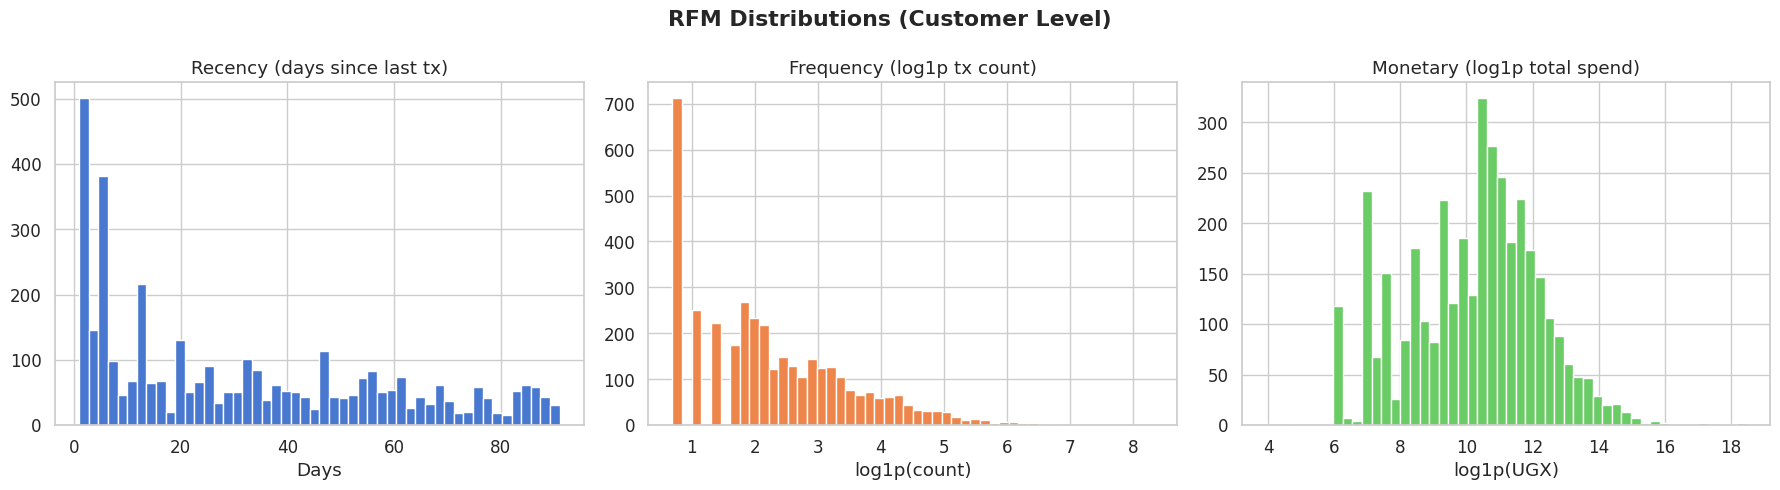

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RFM Distributions (Customer Level)", fontweight="bold")

axes[0].hist(rfm["Recency"], bins=50, color=COLORS[0], edgecolor="white")
axes[0].set_title("Recency (days since last tx)")
axes[0].set_xlabel("Days")

axes[1].hist(np.log1p(rfm["Frequency"]), bins=50, color=COLORS[1], edgecolor="white")
axes[1].set_title("Frequency (log1p tx count)")
axes[1].set_xlabel("log1p(count)")

axes[2].hist(np.log1p(rfm["Monetary"]), bins=50, color=COLORS[2], edgecolor="white")
axes[2].set_title("Monetary (log1p total spend)")
axes[2].set_xlabel("log1p(UGX)")

plt.tight_layout()
plt.savefig("../data/processed/eda_rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

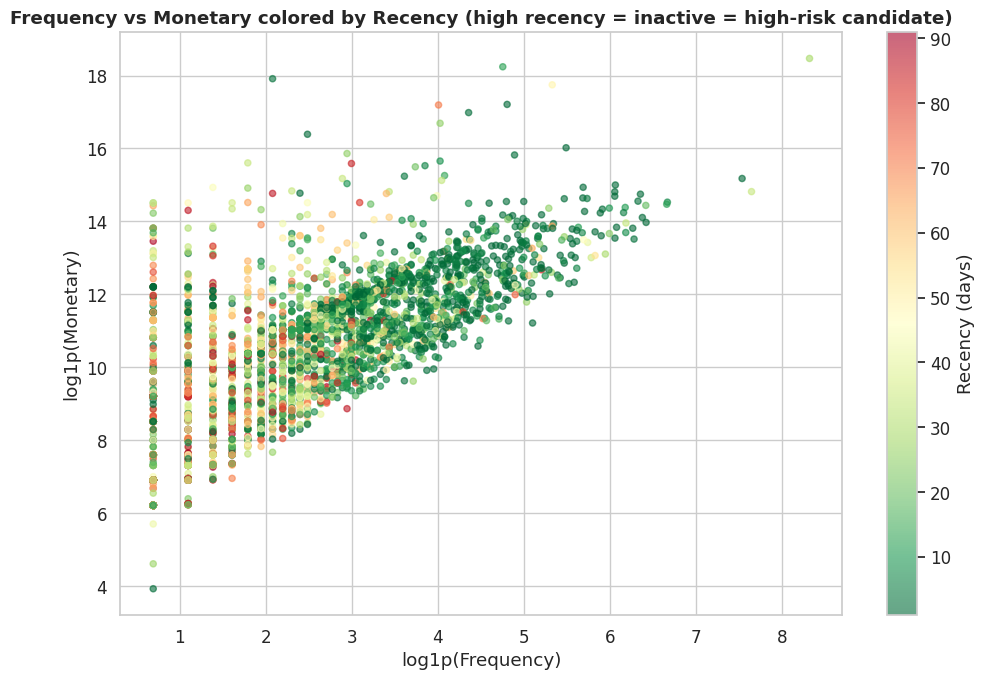

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(np.log1p(rfm["Frequency"]), np.log1p(rfm["Monetary"]),
                     c=rfm["Recency"], cmap="RdYlGn_r", alpha=0.6, s=20)
plt.colorbar(scatter, ax=ax, label="Recency (days)")
ax.set_xlabel("log1p(Frequency)")
ax.set_ylabel("log1p(Monetary)")
ax.set_title("Frequency vs Monetary colored by Recency (high recency = inactive = high-risk candidate)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/eda_rfm_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Key Insights Summary

### Top 5 Insights

---

**Insight 1 — Extreme class imbalance in the fraud label**  
Fraudulent transactions account for fewer than 1% of all records. Any model trained directly on `FraudResult` as a target will be dominated by the majority class. The RFM proxy target must be evaluated for similar imbalance; if so, `class_weight="balanced"` or oversampling (SMOTE) will be required at training time.

---

**Insight 2 — Amount is heavily right-skewed with negative values (credit reversals)**  
The `Amount` column includes negative values (credits back to customers), while `Value` is always positive. The 99th percentile of `Value` is orders of magnitude above the median. Log-transformation is essential before distance-based models (e.g., K-Means for RFM clustering). Negative-amount transactions may indicate disputes or returns and should be tracked as a separate behavioral feature.

---

**Insight 3 — Customer engagement follows a power-law distribution**  
The CDF shows the top 10% of customers account for a disproportionate share of transactions. Most customers transact very few times (median in the low single digits). This long-tail distribution directly motivates the RFM proxy: the high-risk K-Means cluster will correspond to this large group of infrequent, low-spend customers.

---

**Insight 4 — Product category is a strong fraud signal**  
`ProductCategory` shows distinct fraud rates across categories. Airtime dominates by volume, but financial services and utility bills show elevated fraud rates. This makes `ProductCategory` a high-value feature for WoE encoding and tree-based models alike.

---

**Insight 5 — No structural missing values, but zero-value transactions exist**  
The dataset has no missing values, simplifying imputation design. However, `Value == 0` transactions exist and likely represent failed or administrative events. These should be flagged as a per-customer binary feature during engineering, as they may signal platform disengagement.

---

### Feature Engineering Implications

| Observation | Action in Task 3 / Task 4 |
|-------------|---------------------------|
| Right-skewed Amount/Value | log1p transform before scaling |
| Negative Amount values | Separate debit_count and credit_count per customer |
| Power-law tx count distribution | StandardScaler on log-RFM before K-Means |
| No missing values | SimpleImputer as pipeline safety net |
| High-cardinality ProductId | Aggregate to ProductCategory level; WoE encode |
| Time patterns (hour, weekday) | Extract hour, dayofweek, is_weekend features |